# Now that we can find the star position, let's test PSF interpolation

Simple interpolation shift to match the positions, and then scale and subtract

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
# import pyklip

In [3]:
from astropy import stats

from astropy.io import fits
from astropy import units

In [4]:
import matplotlib as mpl
from matplotlib import pyplot as plt

In [5]:
from scipy import interpolate
from scipy import optimize

In [6]:
from coronspec_tools import utils as ctutils
from coronspec_tools import misc as ctmisc
from coronspec_tools import observing_sequence, sdi_tools, interp_psf
import agplot

In [7]:
agplot.styles.notebook_style()

In [8]:
# data_files = sorted(Path("/Volumes/agdisk/hst_17092_data/MAST_2025-04-09T1710/HST/").glob("of*/*fits"))
data_files = sorted(Path("../../data/MAST_2024-03-21T13_06_42.642Z/MAST_2024-03-21T13_06_42.642Z/HST/").glob("OF*/*fits"))

In [9]:
len(data_files)

38

In [10]:
file_managers = {}
for f in data_files:
    ftype = f.stem.split("_")[1]
    if ftype not in file_managers.keys():
        file_managers[ftype] = []
    file_managers[ftype].append(f)
for ft in file_managers:
    file_managers[ft] = ctutils.organize_files_by_header(file_managers[ft])

In [11]:
%matplotlib inline

## Make ObsSeq objects

In [17]:
obs_crj = {}
for obset_id, group in file_managers['crj'].groupby("OBSET_ID"):
    unocc_aper = '52X0.2E1'
    occ_aper = '52X0.2F1'
    sx1_row = file_managers['sx1'].query(f"PROPAPER == '{unocc_aper}' and OBSET_ID == '{obset_id}'").squeeze()
    sx1_file = Path(sx1_row['filepath'])
    
    unocc_file = Path(group.set_index("ROOTNAME").loc[sx1_row['ROOTNAME'], 'filepath'])
    occ_rows = group.query(f"PROPAPER == '{occ_aper}' and WAVECAL != 'N/A'")
    for ind, occ_row in occ_rows.iterrows():
        print(occ_row['ROOTNAME'])
        rootname = occ_row['ROOTNAME']
        occ_file = Path(occ_row['filepath'])
        obs = observing_sequence.ObsSeq(
            sx1_file=sx1_file,
            unocc_file=unocc_file,
            occ_file=occ_file,
            trace_width=21,
            occ_stamp_width=101,
            contrast=False,
            median_clean=10
        )
        obs_crj[f"{rootname}"] = obs

of0i01020


of0i01030


of0i02020


of0i02030


of0i03020


of0i04020


In [14]:
obs_sx2 = {}
for obset_id, group in file_managers['sx2'].groupby("OBSET_ID"):
    unocc_aper = '52X0.2E1'
    occ_aper = '52X0.2F1'
    sx1_row = file_managers['sx1'].query(f"PROPAPER == '{unocc_aper}' and OBSET_ID == '{obset_id}'").squeeze()
    sx1_file = Path(sx1_row['filepath'])
    
    unocc_file = Path(group.set_index("ROOTNAME").loc[sx1_row['ROOTNAME'], 'filepath'])
    occ_rows = group.query(f"PROPAPER == '{occ_aper}' and WAVECAL != 'N/A'")
    for ind, occ_row in occ_rows.iterrows():
        print(occ_row['ROOTNAME'])
        rootname = occ_row['ROOTNAME']
        occ_file = Path(occ_row['filepath'])
        obs = observing_sequence.ObsSeq(
            sx1_file=sx1_file,
            unocc_file=unocc_file,
            occ_file=occ_file,
            trace_width=21,
            occ_stamp_width=101,
            contrast=False,
            median_clean=10
        )
        obs_sx2[f"{rootname}"] = obs

of0i01020


of0i01030


of0i02020


of0i02030


of0i03020


of0i04020


## Compare FLT and SX2 wcs

In [15]:
obs_sx2.keys()

dict_keys(['of0i01020', 'of0i01030', 'of0i02020', 'of0i02030', 'of0i03020', 'of0i04020'])

In [18]:
fobs = obs_crj['of0i02020']
sobs = obs_sx2['of0i02020']

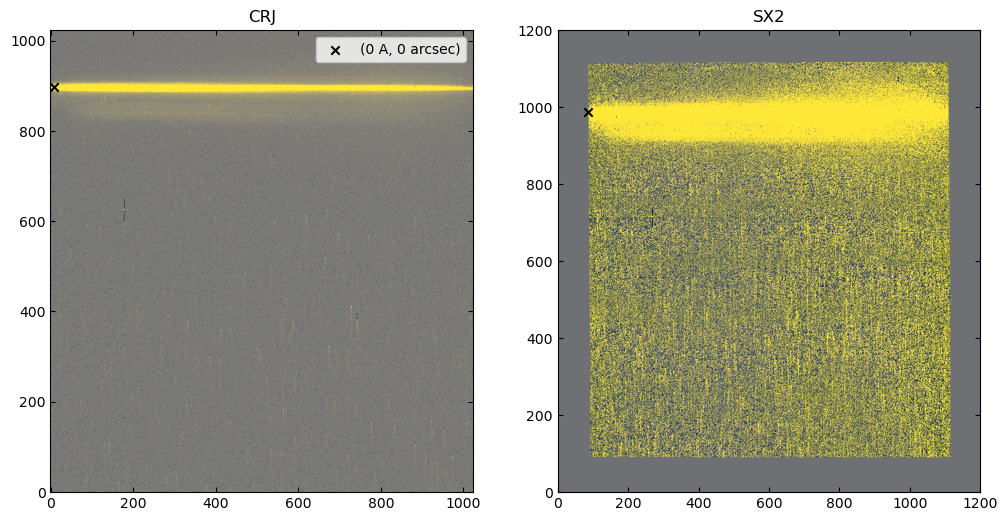

In [22]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
ax = axes[0]
ax.set_title("CRJ")
ax.imshow(fobs.unocc_img, **ctmisc.img_vrange(fobs.occ_img), aspect='auto')
ax.scatter(*fobs.unocc_wcs.world_to_pixel(fobs.wlsol[0], 0*units.deg), marker='x', c='k', label="(0 A, 0 arcsec)")
# ax.axhline(fobs.occ_row, c='k', ls='--')
# ax.set_ylim(400, 600)
ax.legend()

ax = axes[1]
ax.set_title("SX2")
ax.imshow(sobs.unocc_img, **ctmisc.img_vrange(sobs.occ_img), aspect='auto')
ax.scatter(*sobs.unocc_wcs.world_to_pixel(sobs.wlsol[0], 0*units.deg), marker='x', c='k')
# ax.axhline(sobs.occ_row-10, c='k', ls='--')
# ax.set_ylim(500, 700)

The SX2 WCS is clearly shifted too high. Can we measure how far it is off? What are the values of the corners of the FLT file, and where to they map onto the SX2?

In [23]:
corners_world = fobs.occ_wcs.pixel_to_world(
    [0, fobs.occ_img.shape[1], 0, fobs.occ_img.shape[1]],
    [0, 0, fobs.occ_img.shape[0], fobs.occ_img.shape[0]],
)

In [24]:
%matplotlib inline

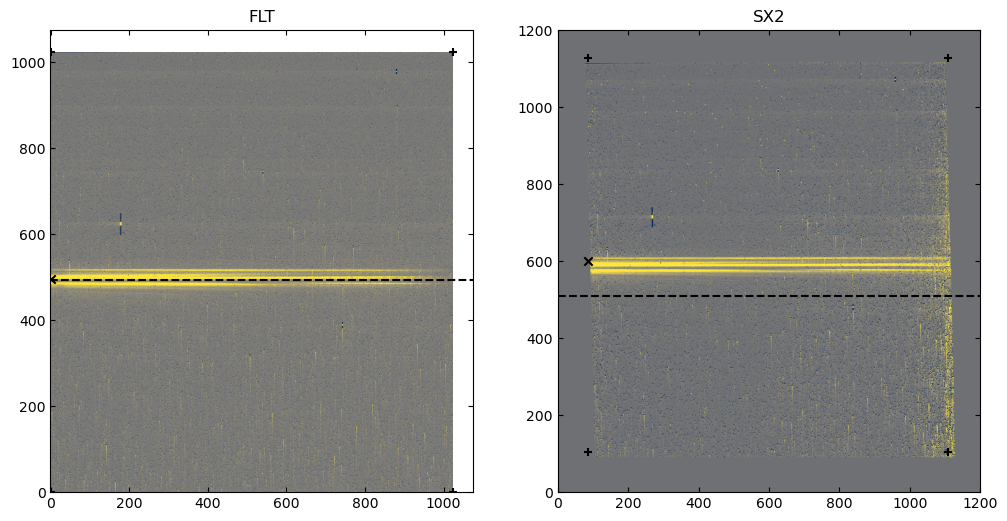

In [25]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
ax = axes[0]
ax.set_title("FLT")
ax.imshow(fobs.occ_img, **ctmisc.img_vrange(fobs.occ_img), aspect='auto')
ax.scatter(*fobs.occ_wcs.world_to_pixel(fobs.wlsol[0], 0*units.deg), marker='x', c='k')
ax.axhline(fobs.occ_row, c='k', ls='--')
ax.scatter(*fobs.occ_wcs.world_to_pixel(*corners_world), marker='+', c='k')
# ax.set_ylim(400, 600)

ax = axes[1]
ax.set_title("SX2")
ax.imshow(sobs.occ_img, **ctmisc.img_vrange(sobs.occ_img), aspect='auto')
ax.scatter(*sobs.occ_wcs.world_to_pixel(sobs.wlsol[0], 0*units.deg), marker='x', c='k')
ax.axhline(sobs.occ_row, c='k', ls='--')
ax.scatter(*sobs.occ_wcs.world_to_pixel(*corners_world), marker='+', c='k')

# ax.set_ylim(500, 700)

In [ ]:
sobs.occ_wcs.pixel_to_world(104, 91)

In [ ]:
sobs.wlsol

## test wl scaling with the wcs

In [ ]:
ref_wl = -1
scale = fobs.wlsol[ref_wl]/fobs.wlsol
rows, cols = np.mgrid[:fobs.occ_img.shape[0], :fobs.occ_img.shape[1]]
wls, seps = fobs.occ_wcs.pixel_to_world(cols.ravel(), rows.ravel())

In [ ]:
scaled_rows, scaled_cols = fobs.occ_wcs.world_to_pixel(wls, seps)

In [ ]:
scaled_img = sdi_tools.rescale_img_with_wcs(fobs.occ_img, fobs.occ_wcs, fobs.occ_sep, scale)

In [ ]:
# plt.imshow(fobs.occ_img, **ctmisc.img_vrange(fobs.occ_img))
plt.imshow(scaled_img, **ctmisc.img_vrange(scaled_img, 0.05, 0.99))
x, y = sdi_tools.compute_scaled_psf_trace_wcs(
    fobs.occ_wcs.pixel_to_world(0, 516)[1],
    fobs.occ_wcs,
    fobs.wlsol,
    ref_wl,
)
plt.plot(x, y, ls='--', c='k', alpha=0.5)

## Compute the X/Y values of a hypothetical PSF, for masking and testing

In [ ]:
cand_sep = fobs.occ_wcs.pixel_to_world(0, 500)[1]

In [ ]:
fobs.occ_wcs.pixel_to_world(*np.mgrid[:10, :10])[0].shape

In [ ]:
plt.imshow(scaled_img, **ctmisc.img_vrange(scaled_img), aspect='auto')
for ref_ind in np.arange(0, fobs.wlsol.size+50, 100):
    x, y = sdi_tools.compute_scaled_psf_trace_wcs(
        cand_sep,
        fobs.occ_wcs,
        fobs.wlsol,
        ref_ind
    )
    plt.plot(x, y, ls='--', c='k')
plt.ylim(400, 600)